# Practical: Data Analysis & Vectors

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
warnings.filterwarnings('ignore')


## Q1. Distance Matrix with NumPy Broadcasting

You have 3 delivery locations (group A) and 2 warehouses (group B), given as 2D coordinates:

In [2]:
A = np.array(
    [[1, 2],
    [4, 6],
    [7, 1]])

B = np.array(
    [[0, 0],
    [5, 5]] )

1. Reshape A and B for broadcasting: A_exp = A[:, np.newaxis, :] and B_exp = B[np.newaxis, :, :] . Print both
shapes.

In [153]:
A_exp = A[:, np.newaxis, :]
B_exp = B[np.newaxis,:, :]
print(A_exp)
print(A.shape, B.shape, sep="\n")
print(A_exp.shape, B_exp.shape, sep="\n")

[[[1 2]]

 [[4 6]]

 [[7 1]]]
(3, 2)
(2, 2)
(3, 1, 2)
(1, 2, 2)


2. Compute the difference diff = A_exp - B_exp . Print its shape.

In [4]:
diff = A_exp - B_exp
diff.shape

(3, 2, 2)

3. Compute the Euclidean distance matrix using np.sqrt(np.sum(diff**2, axis=2)) . Print the result rounded to 2 decimal
places.

In [126]:
dist_matrix = np.round(np.sqrt(np.sum(diff**2, axis=2)), 2)
print(dist_matrix)

[[2.24 5.  ]
 [7.21 1.41]
 [7.07 4.47]]


4. In a Markdown cell, answer: which warehouse (B0 or B1) is closer on average to all delivery locations?

In [131]:
dff = pd.DataFrame(dist_matrix)
dff.mean()

0    5.506667
1    3.626667
dtype: float64

Since B1 on average smaller than B0 it is more closer to all delivery locations


## Q2. Given:

p = [2, 1, -3]

q = [4, -2, 1]

1. Compute p · q using four different methods (loop, np.dot , np.multiply + sum , np.matmul ).

2. Using the geometric formula p · q = ||p|| × ||q|| × cos(θ) , compute the angle θ between p and q in both
radians and degrees.

3. Interpret the angle: are the vectors more aligned, perpendicular, or opposing?
4. Now create a vector r that is guaranteed to be orthogonal to p (dot product = 0) in 3D. Verify it numerically.


In [21]:
# 1
p = np.array([2, 1, -3])
q = np.array([4, -2, 1])
ans = 0
for i in range(3):
   ans += p[i]*q[i]
print(ans)

print(np.dot(p, q))
print(np.matmul(p, q))
print(sum(np.multiply(p, q)))

3
3
3
3


In [26]:
# 2
angle = np.arccos(np.dot(p, q) / (len(p) * len(q)))
print(angle, np.degrees(angle), sep=" ")

1.2309594173407747 70.52877936550931


3. Since the angle is 70.5 which is < 90 they are aligned

In [134]:
# 4
r = np.array([-p[1], p[0], 0])
print(r, np.dot(p,r), sep='\n')
# dot product = 0 they are orthogonal


[-1  2  0]
0


## Q3. Given vectors:

u = [3, -4]

v = [-6, 8]

1. Compute the magnitudes of u and v . What is the ratio ||v|| / ||u|| ? What does this ratio tell you?

2. Compute the unit vectors of u and v . What do you notice?

3. Are u and v parallel? Justify your answer mathematically (do not just plot — use the dot product and magnitudes).

4. On a single plot, draw u , v , and the unit vector of u . Add a legend and dashed axes

In [31]:
# 1
u = np.array([3, -4])
v = np.array([-6, 8])
mag1 = np.linalg.norm(u)
mag2 = np.linalg.norm(v)
print(mag1, mag2, sep=' ')
print(mag2/ mag1)
# ratio means that length of the vector v is twice bigger that u

5.0 10.0
2.0


In [33]:
# 2
unit1 = u / mag1
unit2 = v / mag2
print(unit1, unit2)

[ 0.6 -0.8] [-0.6  0.8]


In [137]:
# 3
print(abs(np.dot(u, v)), mag1*mag2)
# since absolute dot product == mag1*mag2 they are parallel

50 50.0


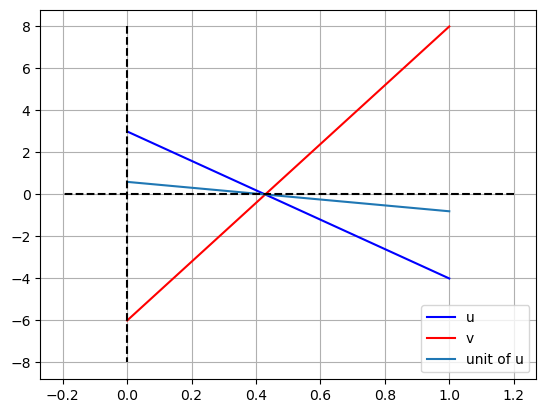

In [125]:
# 4
plt.plot(u,color='blue', label='u')
plt.plot(v, color='red', label='v')
plt.plot(unit1, label='unit of u')
plt.plot([1.2, -0.2], [0,0], 'k--')
plt.plot([0, 0], [8,-8], 'k--')
plt.grid()
plt.legend()
plt.show()

## Q4. Pandas: Load, Explore & Clean

Load the MPG dataset (car fuel efficiency), a dataset built into Seaborn:

df = sns.load_dataset('mpg')

Each row is a car model. Key columns: mpg (miles per gallon), cylinders , weight , horsepower , origin , name .

1. Print the shape and display the first 5 rows.

2. Print the number of missing values per column. Which column has missing values?

3. Create df_clean by dropping rows with any missing values using .dropna() . Print the new shape.

4. Print basic summary statistics using .describe() . What is the average mpg ?

In [41]:
# 1
df = sns.load_dataset('mpg')
print(df.shape, df.head(), sep='\n')

(398, 9)
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [45]:
# 2
df.isna().sum()
# horsepower has missing values

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [48]:
df_clean = df.dropna()
print(df.shape, df_clean.shape, sep='\n')

(398, 9)
(392, 9)


In [49]:
df_clean.describe()
# average mpg = 23.445918

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## Q5. Filtering, Sorting & GroupBy

Using df_clean from Q2:

1. Filter cars with mpg > 30 (fuel-efficient cars). Print how many there are.

2. Sort the dataset by mpg in descending order and display the top 5 most fuel-efficient cars — show only the columns name ,
mpg , cylinders , origin .

3. Use GroupBy to find the average mpg per country of origin ( origin ). Print the result.

4. In one Markdown sentence, state which country produces the most fuel-efficient cars on average.

In [57]:
print(df_clean[df_clean.mpg > 30].count()[0])

83


In [60]:
df_clean.sort_values(by="mpg", ascending=False)[["name", "mpg", "cylinders", "origin"]].head()

,name,mpg,cylinders,origin
322,mazda glc,46.6,4,japan
329,honda civic 1500 gl,44.6,4,japan
325,vw rabbit c (diesel),44.3,4,europe
394,vw pickup,44.0,4,europe
326,vw dasher (diesel),43.4,4,europe


In [70]:
df_clean.groupby('origin')['mpg'].mean()

origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64

Japan produces most fuel-efficient cars on average

## Q6. Visualization

Using df_clean , create a figure with two subplots side by side ( figsize=(12, 4) ):

Left subplot: A bar plot of average mpg per origin . Title: 'Average MPG by Country' . Add a y-axis label 'MPG' .

Right subplot: A scatter plot of weight (x-axis) vs mpg (y-axis). Title: 'MPG vs Car Weight' . Add axis labels.

Use plt.tight_layout() and plt.show() . In a Markdown cell, write one observation from the scatter plot.

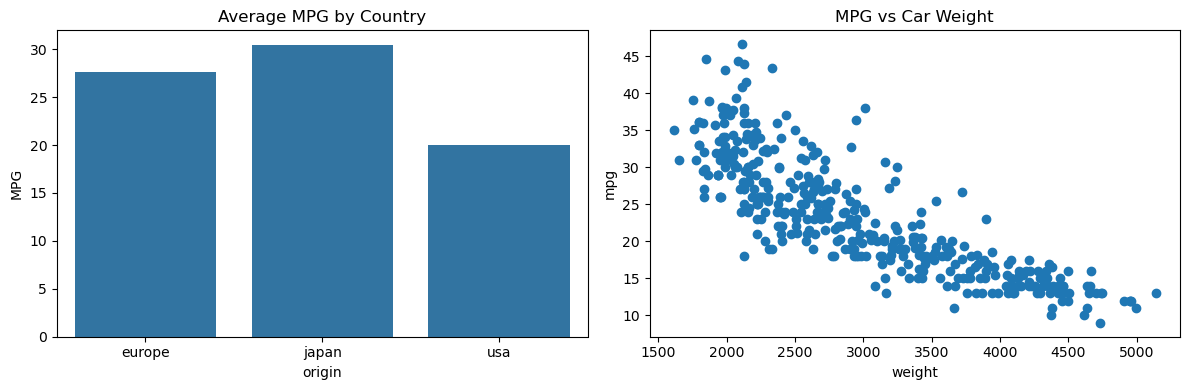

In [151]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
avg_mpg = df_clean.groupby('origin')['mpg'].mean()
sns.barplot(avg_mpg)
plt.ylabel('MPG')
plt.xlabel('origin')
plt.title('Average MPG by Country')

plt.subplot(1, 2, 2)
plt.scatter(df_clean['weight'], df_clean['mpg'])
plt.title('MPG vs Car Weight')
plt.xlabel('weight')
plt.ylabel('mpg')

plt.tight_layout()
plt.show()

When weight increases mpg goes down which means if there is light weighted car it will have more miles per gallon and will be efficient

## Q7. KNN Classification on the Wine Dataset

The Wine dataset contains chemical measurements of wines from 3 different cultivars (classes 0, 1, 2). It is loaded from sklearn.
1. Load the dataset and print feature_names , target_names , and the shape of the data. 

2. Split into train/test sets (75% train, 25% test) using random_state=42 .

3. Train a KNeighborsClassifier with n_neighbors=5 . Print the test accuracy.

4. In a Markdown cell, state in one sentence whether this is a classification or regression problem and why

In [93]:
wine = load_wine()
print(wine.data.shape)
print(wine.feature_names)
print(wine.target_names)


(178, 13)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']


In [105]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=wine.target
)

In [106]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print(knn.score(X_test, y_test))

0.7777777777777778


This is classification problem. Becuse in target variables we have wine classes class0, class1, class2